# Titanic Dataset — Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Titanic dataset obtained from Kaggle.

The main objectives are:

* Understand the structure of the training and test datasets
* Explore numerical and categorical features
* Identify missing values
* Analyze the distribution of passenger characteristics
* Explore the distribution of the target variable
* Investigate relationships between passenger features and survival


## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys


In [3]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

## 1. Load Dataset

The Titanic dataset contains two separate files: `train.csv` and `test.csv`.

The training dataset contains the target variable `Survived`, while the test dataset does not contain this column.

Both datasets are loaded separately so that their structures and features can be examined before the preprocessing stage.



In [4]:
from src.data_loader import *
df_train=load_train_data()
df_test=load_test_data()

In [5]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Dataset Overview

In this section, we examine the structure and basic information of both the training and test datasets.

The number of rows, columns, data types, and available features are inspected to better understand the dataset before performing further analysis.


In [7]:
# Number of columns and rows
print(f'Shape train dataset : {df_train.shape}')
print(f'Shape test dataset : {df_test.shape}')

Shape train dataset : (891, 12)
Shape test dataset : (418, 11)


## 3. Missing Values

Missing values are an important part of the exploratory data analysis process.

The number of missing values in both the training and test datasets is examined to identify columns that may require special treatment during preprocessing.


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Cabin , Age and Embarked are null
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [11]:
# Cabin & Age are null
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## 4. Descriptive Statistics

Descriptive statistics are used to understand the distribution and range of the numerical features.

Statistics such as the mean, standard deviation, minimum, maximum, and quartiles are examined for the numerical variables in the training dataset.


In [12]:
df_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [13]:
df_test.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Peter, Master. Michael J",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292
Cabin,91,76,B57 B59 B63 B66,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [15]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 5. Target Variable — Survived

The target variable in the Titanic dataset is `Survived`.

It indicates whether a passenger survived the disaster:

* `0` — Did not survive
* `1` — Survived

The distribution of the target variable is visualized to understand the balance between the two classes.


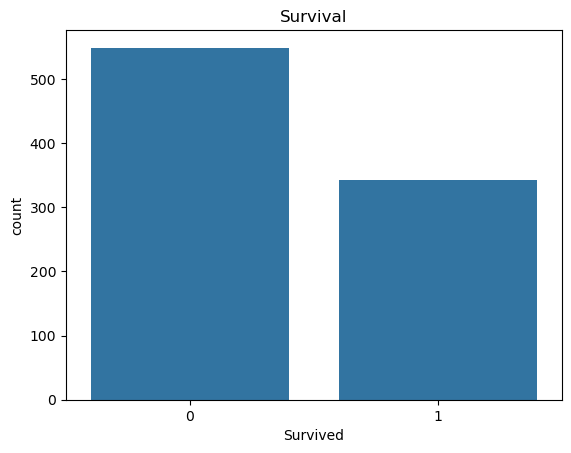

In [16]:
sns.countplot(data=df_train,x='Survived')
plt.title('Survival')
plt.show()

## 6. Categorical Feature Analysis

Several categorical features describe characteristics of the passengers.

Important categorical variables include:

* `Sex`
* `Pclass`
* `Embarked`

The distribution of these features is explored to understand the characteristics of the passengers in the dataset.


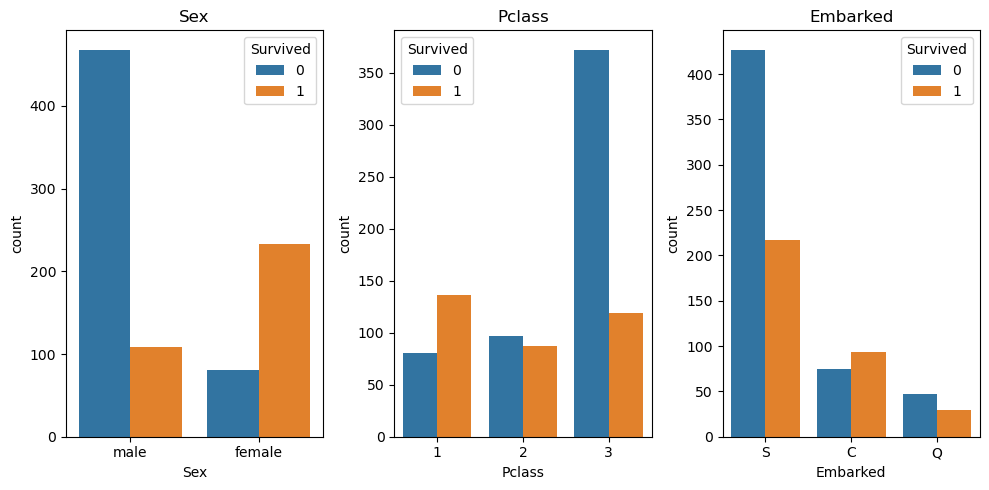

In [30]:
plt.figure(figsize=(10,5))
cat_columns=df_train[['Sex','Pclass', 'Embarked']]
for i,col in enumerate(cat_columns):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df_train,x=col,hue='Survived')
    plt.title(col)
plt.tight_layout()
plt.show()  

## 7. Numerical Feature Analysis

The Titanic dataset contains several numerical features, including:

* `Age`
* `Fare`
* `SibSp`
* `Parch`

Histograms are used to examine their distributions, ranges, and potential outliers.
s

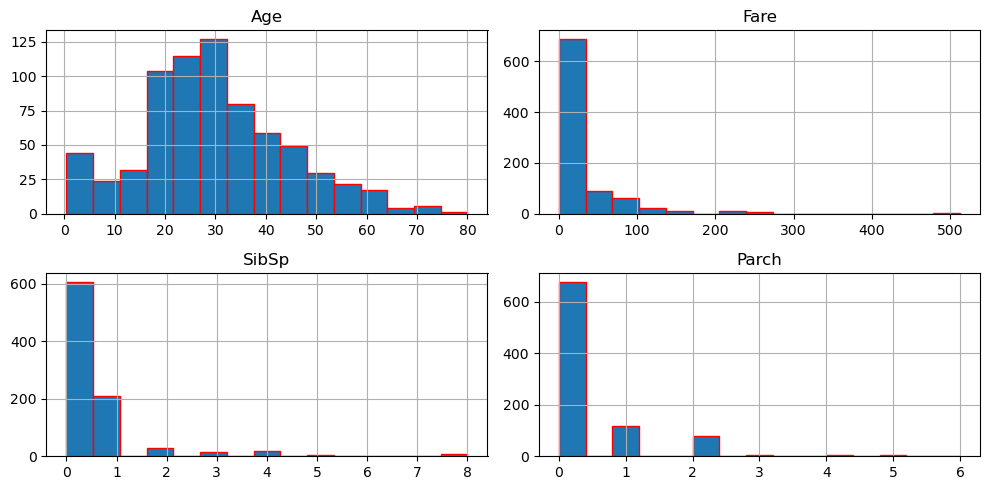

In [32]:
plt.figure(figsize=(10,5))
num_columns=df_train[['Age','Fare','SibSp','Parch']]
for i,col in enumerate(num_columns):
    plt.subplot(2,2,i+1)
    df_train[col].hist(bins=15,edgecolor='red')
    plt.title(col)
plt.tight_layout()
plt.show()  

##  Survival by Sex

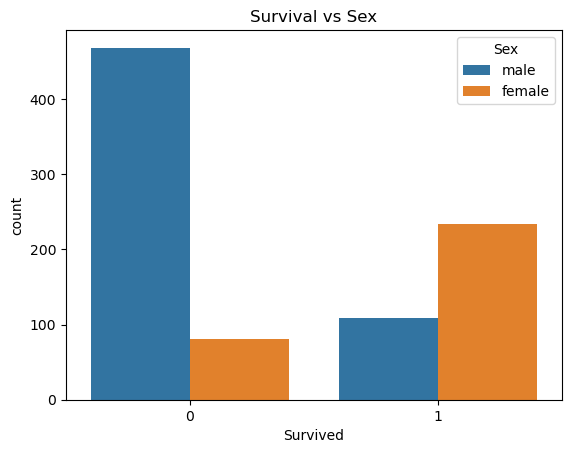

In [ ]:
sns.countplot(data=df_train,x='Survived',hue='Sex')
plt.title('Survival vs Sex')
plt.show()

In [ ]:
df_train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Survived by Pclass

<Axes: xlabel='Survived', ylabel='count'>

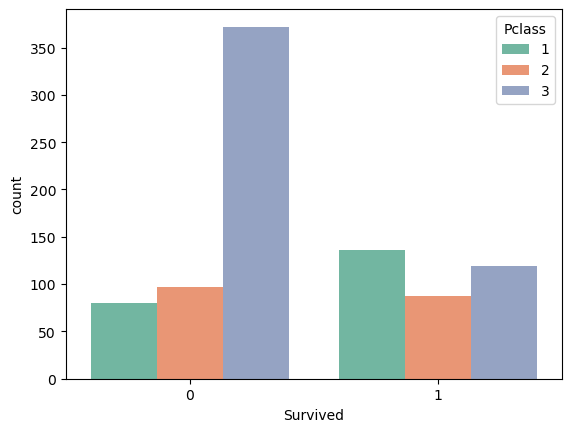

In [ ]:
sns.countplot(data=df_train,x='Survived',hue='Pclass',palette='Set2')
plt.title('Survival vs Passenger Class')
plt.show()

In [ ]:
df_train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Age and Survival





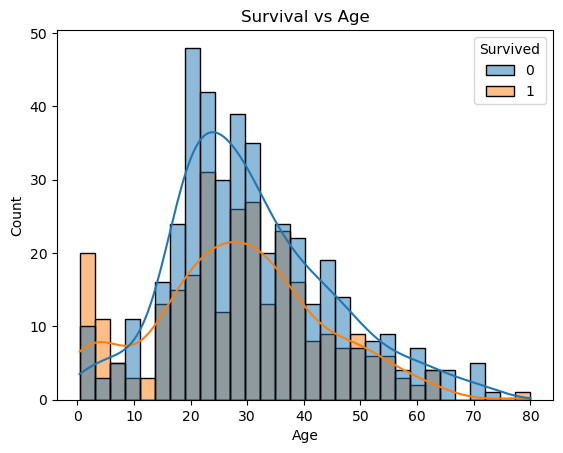

In [ ]:
sns.histplot(data=df_train,x='Age',hue='Survived',bins=30,kde=True)
plt.title('Survival vs Age')
plt.show()

## 8. Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables in the training dataset.

The correlation matrix provides an overview of how numerical features are related to each other and to the target variable.


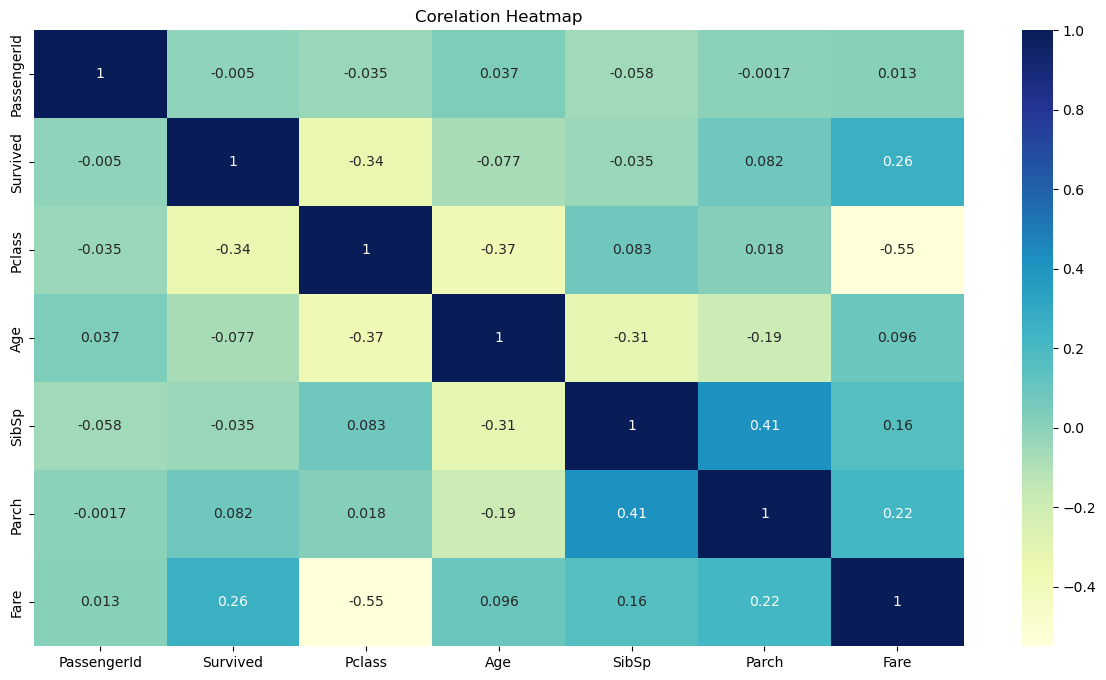

In [34]:
plt.figure(figsize=(15,8))
corr=df_train.select_dtypes('number').corr()
sns.heatmap(corr,annot=True,cmap='YlGnBu')
plt.title('Corelation Heatmap')
plt.show()

## 9. Summary

The exploratory data analysis provided an overview of the Titanic dataset and its main characteristics.

The analysis examined:

* Dataset structure
* Missing values
* Numerical and categorical features
* Target variable distribution
* Relationships between passenger features and survival

The findings from this analysis will be used to guide the data preprocessing and feature engineering steps in the next stage of the project.
